## Design of Protein Binding Sites

Ledidi can turn any machine learning model that makes predictions on biological sequences into an edit designer. This means that if you have a model that already makes predictions for the sort of biochemical activity you are interested in, e.g., protein binding, accessibility, transcription, etc, you can use that model with Ledidi to design sequences without even needing to train anything!

As an initial evaluation of Ledidi, let's use it to create some protein binding sites, confirm that the designed edits yield the intended effect, and then take a look at what the proposed edits were. Because protein binding is a fairly straightforward process for many TFs, the results should also be straightforward to interpret.

The first step in using Ledidi is finding an oracle model to use for design. Here, we want to design protein binding sites so we will use BPNet models that use genome sequence to predict protein binding in the forms of basepair resolution profiles and total log counts in the region. In theory, we could optimize either one of these two tasks, but for demonstration purposes it is more convenient to focus on the log count prediction task because it is a simple number. 

We have trained a BPNet model for each of eight proteins in K562 whose ChIP-seq data is on the ENCODE portal. Each model was trained on the union of reads from two replicate BAM files mapped at basepair resolution and separated out by strand. These models were trained using the `bpnet-lite` repository.

You can download the GATA2 model used here, as well as the other BPNet models used in the paper, from the following link: https://zenodo.org/records/14604495

#### Loading an oracle BPNet model

Let's begin by loading up a pre-trained model that predicts GATA2 binding. For those who are interested in the technical details, we trained this BPNet model using the `bpnet-lite` repository using the default settings for BPNet models. It was trained to predict stranded signals derived from the union of two replicate BAM files from the ENCODE portal (accession: ENCSR000BKM) that were converted to bigwig files using `bam2bw`. 

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8' # Ignore this for now. Only necessary for reproducibility.

import torch

model = torch.load("../../../../models/bpnet/GATA2.torch", weights_only=False)

There are two technical details of the BPNet models we need to account for before they can be used by Ledidi. First, they take a control track in addition to genome sequence to adjust for biases in the mapping step. Because Ledidi assumes only a single input to the model, we need to use `ControlWrapper`, which just automatically creates and passes in an all-zeroes control of the same batch size as the data, removing our need to account for it. Second, the model makes predictions for both profile and counts, so we need to use `CountWrapper` to remove the profile output. After using these two wrappers, we have an object that only takes in sequence and outputs a single number per example. Most model complexities can be removed through the use of a wrapper like this.

Please note that these technical details are very BPNet-specific and are not required of all models you apply Ledidi to.

In [2]:
from bpnetlite.bpnet import ControlWrapper
from bpnetlite.bpnet import CountWrapper

model = CountWrapper(ControlWrapper(model))

Next, we need a region that we will try to increase protein binding in. This choice is very important and depends on what precisely you are trying to do. 

One could start off with a completely randomly generated sequence in principle, but then Ledidi would offer no real advantage over other de novo design algorithms because there is no benefit for keeping the original sequence intact.

Alternatively, one could choose negative regions in the genome as examples of real genomic sequence -- in contrast to randomly generated sequence -- and there would be a benefit in reducing the number of proposed edits. Namely, that we can start with a sequence whose public data suggests a good starting point and reduce unintented consequences by limiting the number of proposed edits.

Finally, if we have a specific region in mind (e.g., a known promoter or regulatory element) we should use that as our starting point.

Here, we will choose the promoter of the SMYD3 gene, which is lysine methyltransferase that is known to play a role in cancer.

In [3]:
import pyfaidx
from tangermeme.utils import one_hot_encode

chrom, mid = "chr1", 246_507_312

X = pyfaidx.Fasta("../../../../common/hg38.fa")[chrom][mid-1057:mid+1057].seq.upper()
X = one_hot_encode(X).unsqueeze(0).float().cuda()

Note that the choice of a GATA2 binding model and of the SMYD3 gene are entirely for demonstration, rather than some known biological interaction, but are useful because the task then clearly becomes to induce GATA2 binding at this promoter. So, first we should check whether GATA2 is predicted to bind there.

In [4]:
from tangermeme.predict import predict

y = predict(model, X)
y

tensor([[0.4569]])

No. Such a small log count suggests that GATA2 does not already bind here. Looks like we are good to go to design GATA2 binding sites.

#### Using Ledidi

Now that we have our model and our initial sequence, we can use Ledidi to design edits. We will begin by asking Ledidi to design edits that increase model predictions by 4 over what the predictions were for the original sequence. Since these values are log counts, this is asking for around a 50x increase in reads.

In [5]:
y_bar = y + 4
y_bar

tensor([[4.4569]])

Using Ledidi is straightforward. You pass in the model, the initial sequence, the desired output, and any other parameters that are relevant to the `ledidi` function. This will return a batch of designed sequences.

In [6]:
from ledidi import ledidi

x_bar = ledidi(model, X, y_bar, verbose=True)

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=27.69	output_loss=0.1267	total_loss=2.895	time=0.648


iter=200	input_loss=24.5	output_loss=0.149	total_loss=2.599	time=0.2581
iter=F	input_loss=21.25	output_loss=0.2381	total_loss=2.363	time=1.024


It is just that simple! Looks like Ledidi proposed an average of roughly twenty edits across the batch of edited sequence it returned, and these edits reduced the distance between the original and desired output from 16 (4\*\*2 because we are using Euclidean distance as the loss) to much less than 1. `x_bar` is a tensor of one-hot encoded sequences containing the proposed edits.

When using the `verbose` option, one line will be returned at the beginning of design (iter=I) before any edits have been made, one line will be returned at the end of design (iter=F) showing the best batch of designs that were constructed, and one line will be returned every `report_iter` number of iterations.

Looks like Ledidi was able to run on this BPNet model with this objective on an V100 in less than 2 seconds. This timing depends on a few things, including whether this is the first time running the model (there is a start-up cost that has to be paid once). 

<b>However, a challenge with Ledidi and PyTorch is that PyTorch has trouble being reproducible due to issue at the CUDA/CuDNN because some unexpected operations are done approximately for big speed boosts. Because Ledidi is sampling based, even tiny differences (even only different at machine precision) from this approximation that would not normally be noticed will cause different samples to be drawn. These results will almost certainly be just as good, but just not the same.</b>

We can force determinism using `torch.use_deterministic_algorithms(True)` setting the flag set at the top of the notebook, and setting a manual seed before running. None of these steps are sufficient by themselves.

In [7]:
torch.manual_seed(0); ledidi(model, X, y_bar, verbose=True); print()
torch.manual_seed(0); ledidi(model, X, y_bar, verbose=True); print("\n")

torch.use_deterministic_algorithms(True) 

torch.manual_seed(0); ledidi(model, X, y_bar, verbose=True); print()
torch.manual_seed(0); _ = ledidi(model, X, y_bar, verbose=True)

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=30.56	output_loss=0.03932	total_loss=3.096	time=0.2587


iter=200	input_loss=22.0	output_loss=0.1489	total_loss=2.349	time=0.2571


iter=300	input_loss=29.06	output_loss=0.05068	total_loss=2.957	time=0.257
iter=F	input_loss=22.0	output_loss=0.1489	total_loss=2.349	time=0.7728

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=31.25	output_loss=0.05029	total_loss=3.175	time=0.2574


...

iter=300	input_loss=32.0	output_loss=0.2534	total_loss=3.453	time=0.2569
iter=F	input_loss=22.31	output_loss=0.1318	total_loss=2.363	time=0.7741


iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=28.25	output_loss=0.134	total_loss=2.959	time=0.5139


iter=F	input_loss=24.75	output_loss=0.09822	total_loss=2.573	time=0.7726

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=28.25	output_loss=0.134	total_loss=2.959	time=0.2709


iter=F	input_loss=24.75	output_loss=0.09822	total_loss=2.573	time=0.5305


Note the difference in speed. On this machine, it takes only around 1 second to run Ledidi normally but over 10 seconds to run Ledidi (specifically, to run the underlying BPNet model) with full determinism enabled. Despite this slowdown, we do get reproducible results. The choice is yours -- when you need completely reproducible results, use the above steps, but otherwise the results are likely just as good each time you run it. I recommend that you only use determinism when debugging something that needs it.

Let's run it one more time and this time get the record of statistics during the optimization.

In [8]:
torch.manual_seed(0)

x_bar, history = ledidi(model, X, y_bar, verbose=True, return_history=True)

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=28.25	output_loss=0.134	total_loss=2.959	time=0.2776


iter=F	input_loss=24.75	output_loss=0.09822	total_loss=2.573	time=0.5427


Now, we can take a look at the statistics recorded in the history -- specifically, the input and output losses.

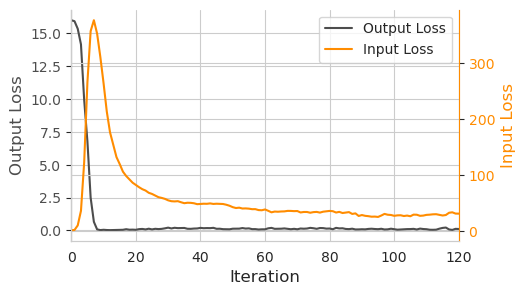

In [9]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

from ledidi.plot import plot_loss

plt.figure(figsize=(5, 3))
ax, _ = plot_loss(history)
ax.set_xlim(0, 120)
plt.show()

Here, we are looking at the input and output losses during training. Because the two live on very different scales -- the input loss is the average number of edits proposed per sequence in that batch, while the output loss is the average distance between the predictions from those edited sequences and the desired output -- `plot_loss` draws them against twin y-axes: the output loss on the left axis and the input loss on the right. Both are read straight from the history dictionary, with no rescaling.

We can see that there are basically three regimes. In the first regime (the first \~7 iterations), the output loss rapidly decreases as edits are rapidly acquired. In the second regime (~7 to ~20 iterations), after the output loss becomes very small, the input loss rapidly decreases as useless edits are discarded. Finally, in the third regime (after ~20 iterations) the input loss slowly decreases as sets of edits with weak effects are exchanged for edits with stronger effects.

Overall, it looks like the design was a success, with only a few edits needed to achieve our goal. But let's directly check some things. First, let's check that the predictions are actually what we want. Once Ledidi has been fit, we can sample as many sets of edits as we want from the underlying distributions using the `n_samples` parameter. This is distinct from `batch_size` because `batch_size` sets the size during training and `n_samples` sets the number of returned designs after the Ledidi weight matrix has been fit. These edits will be highly correlated with each other but give a sense for the distribution of predicted values they induce.

In [10]:
torch.manual_seed(0)

X_bar = ledidi(model, X, y_bar, n_samples=50, verbose=True)
y_hat = predict(model, X_bar).numpy(force=True)

iter=I	input_loss=0.0	output_loss=16.0	total_loss=16.0	time=0.0


iter=100	input_loss=28.25	output_loss=0.134	total_loss=2.959	time=0.2918


iter=F	input_loss=24.75	output_loss=0.09822	total_loss=2.573	time=0.5679


In theory, we can keep sampling from the forward function as long as we want, but 10 batches should be enough for now. Now we can plot the distribution of `y_hat`.

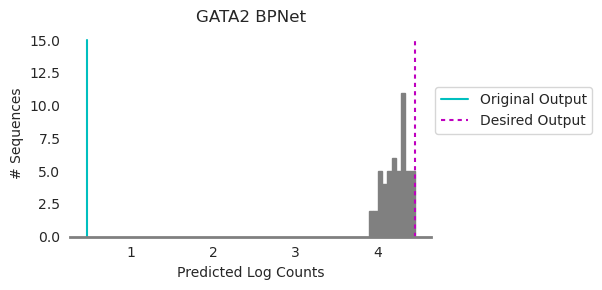

In [11]:
y1 = y_bar.numpy(force=True)[0, 0]
y0 = y1 - 4

plt.figure(figsize=(6, 3))
ax = plt.subplot(111)
plt.title("GATA2 BPNet")
plt.hist(y_hat, facecolor='0.5', edgecolor='0.5')
plt.plot([y0, y0], [0, 15], label="Original Output", c='c')
plt.plot([y1, y1], [0, 15], label="Desired Output", c='m', linestyle=(0, (2, 2)))

plt.legend(loc=(1.01, 0.5))
plt.xlabel("Predicted Log Counts")
plt.ylabel("# Sequences")
seaborn.despine(left=True)
plt.grid(False)
plt.setp(ax.spines.values(), linewidth=2, color='0.5')
    
    
plt.tight_layout()
plt.show()

We began with a sequence whose predicted log counts were at the cyan line and we wanted to generate a sequence whose predicted log counts were at the magenta line. Ledidi generated edits whose distribution is shown in gray. Looks like a pretty good match to the magenta line! Remember that the reason the histogram is not exactly at the desired output is because of the input loss, which is encouraging fewer edits at the cost of not precisely matching the desired output. But, also remember that we do not necessarily need every set of edits to meet the desired output because we can choose which set of edits to use after generation!

Next, we can look at a map of where edits are made and when. Ledidi has a built-in function, `plot_history`, that will show the entire history of where and when edits were proposed across the sequence. 

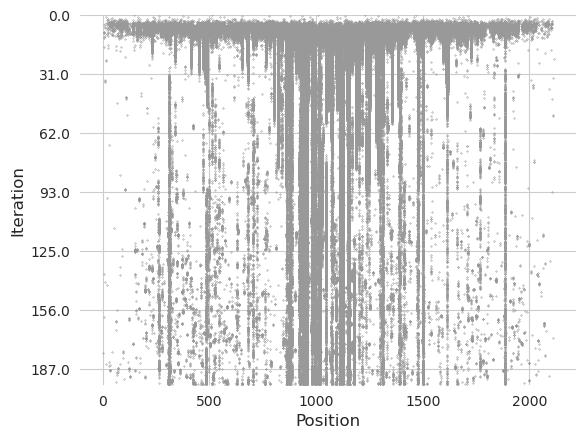

In [12]:
from ledidi.plot import plot_history

plot_history(history)
seaborn.despine(bottom=True, left=True)
plt.show()

Each gray dot represents an edit, with the top of the plot representing the beginning of the design process, the bottom representing the end of the design process, and the positions from left to right representing the positions in the sequence. Vertical streaks indicate positions where an edit has been proposed and then preserved and then sometimes discarded.

We see that the strongest trend is a mist of edits being proposed initially, lining up with the first regime of the plot shown earlier. Then, this mist starts to fade and vertical lines begin to appear. Most of the edits proposed by the end were already being proposed initially, and the thicker lines correspond to entire motifs being proposed. In contrast, some of the more spurious edits that are alone get adopted and then immediately discarded.

#### Pruning Edits

Despite Ledidi including the number of edits as an explicit term in the optimization, some edits that are proposed may only contribute marginally. These edits are likely to be phased out as regime 3 continues, but you can alternatively end this process early and prune them out using a built-in greedy pruning approach.

This greedy pruning approach proceeds as follows: undo each edit individually and record the change in prediction before and after undoing it. Then, undo the edit whose change in prediction is the smallest, provided that the total change in prediction from the original set of edits is no more than some user-provided threshold. Repeat this process until termination. 

In [13]:
from tqdm import tqdm
from ledidi.pruning import greedy_pruning

X_bar_p = torch.cat([greedy_pruning(model, X, xb[None], threshold=0.25, verbose=False) for xb in tqdm(X_bar)])

  0%|                                                                                                                                                                                                                                         | 0/50 [00:00<?, ?it/s]

  2%|████▌                                                                                                                                                                                                                            | 1/50 [00:00<00:07,  6.67it/s]

  4%|█████████                                                                                                                                                                                                                        | 2/50 [00:00<00:06,  7.10it/s]

  6%|█████████████▌                                                                                                                                                                                                                   | 3/50 [00:00<00:07,  6.38it/s]

  8%|██████████████████                                                                                                                                                                                                               | 4/50 [00:00<00:06,  6.60it/s]

...

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌             | 47/50 [00:06<00:00,  6.72it/s]

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████         | 48/50 [00:07<00:00,  6.60it/s]

 98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌    | 49/50 [00:07<00:00,  6.32it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.84it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.82it/s]

This process gets run independently for each set of edits that were proposed, hence the inner loop. We choose a threshold of 0.25, meaning that we will end up with a set of edits that are closer to being a log fold increase of 3.75 rather than 4.

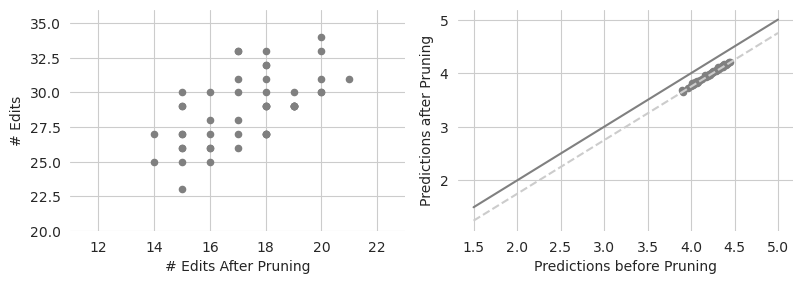

In [14]:
n_edits0 = torch.abs(X_bar - X).sum(dim=(-1, -2)).numpy(force=True) // 2
n_edits1 = torch.abs(X_bar_p - X).sum(dim=(-1, -2)).numpy(force=True) // 2

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.scatter(n_edits1, n_edits0, c='0.5', s=20)
plt.ylim(n_edits0.min() - 3, n_edits0.max() + 2)
plt.xlim(n_edits1.min() - 3, n_edits1.max() + 2)
plt.xlabel("# Edits After Pruning") 
plt.ylabel("# Edits")
seaborn.despine(bottom=True)
    
plt.subplot(122)
y_hat_ = predict(model, X_bar).numpy(force=True)
y_hat_pruned_ = predict(model, X_bar_p).numpy(force=True)

plt.scatter(y_hat_, y_hat_pruned_, s=20, c='0.5')
plt.plot([1.5, 5], [1.5, 5], c='0.5')
plt.plot([1.5, 5], [1.25, 4.75], c='0.8', linestyle='--')
plt.xlabel("Predictions before Pruning")
plt.ylabel("Predictions after Pruning")
seaborn.despine(bottom=True, left=True)


plt.tight_layout()
plt.show()

Looks like the pruning is able to remove quite a few edits, going from an average of around 30 edits to an average of around 16 edits. Some sequences seem to be able to be pruned quite a bit. As expected, none of these proposed sequences exhibit differences in prediction that exceed 0.5 (the dashed gray line) from their original predictions.

There is nothing special about a threshold of 0.25, though. In fact, we can create a gradient of edit counts by moving this threshold from 0 (no change from the original set of edits) to 4 (removing all the edits and going back to the original sequence). Looking at this gradient may be valuable for seeing how many edits we can undo without having to give up much. To speed things up we will only look at the first few sequences.

In [15]:
X_bar_hats, y_bar_hats = [], []

for j, threshold in enumerate(tqdm(numpy.arange(0.0, 4.1, 0.25))):
    X_bar_hat = greedy_pruning(model, X, X_bar[:1], threshold=threshold, verbose=False)
    X_bar_hats.append(X_bar_hat)
    
    y_bar_hat = predict(model, X_bar_hat)
    y_bar_hats.append(y_bar_hat)

X_bar_hats = torch.stack(X_bar_hats)
y_bar_hats = torch.stack(y_bar_hats)

n_edits0 = torch.abs(X_bar - X).sum(dim=(1, 2)).numpy(force=True) // 2
n_edits = torch.abs(X_bar_hats - X[None]).sum(dim=(2, 3)).numpy(force=True) // 2
y_dist = (y_bar_hats[:, :, 0]).numpy(force=True)

  0%|                                                                                                                                                                                                                                         | 0/17 [00:00<?, ?it/s]

 12%|██████████████████████████▍                                                                                                                                                                                                      | 2/17 [00:00<00:01, 11.99it/s]

 24%|████████████████████████████████████████████████████▉                                                                                                                                                                            | 4/17 [00:00<00:01,  6.69it/s]

 29%|██████████████████████████████████████████████████████████████████▏                                                                                                                                                              | 5/17 [00:00<00:02,  5.93it/s]

 35%|███████████████████████████████████████████████████████████████████████████████▍                                                                                                                                                 | 6/17 [00:00<00:02,  5.45it/s]

...

 82%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                       | 14/17 [00:02<00:00,  4.32it/s]

 88%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                          | 15/17 [00:03<00:00,  4.30it/s]

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊             | 16/17 [00:03<00:00,  4.28it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:03<00:00,  4.27it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:03<00:00,  4.78it/s]

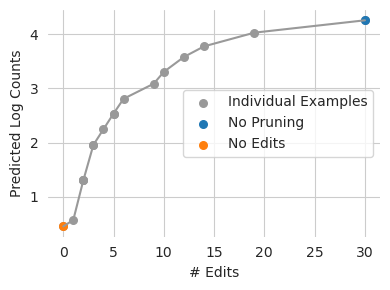

In [16]:
plt.figure(figsize=(4, 3))

plt.plot(n_edits.mean(axis=1), y_dist.mean(axis=1), c='0.6')
plt.scatter(n_edits.mean(axis=1), y_dist.mean(axis=1), c='0.6', s=30, label="Individual Examples")
plt.scatter([n_edits0[:1].mean()], [y_dist[0].mean()], s=30, label="No Pruning")
plt.scatter([0], [y_dist[-1].mean()], s=30, label="No Edits")

plt.legend(loc=5)
plt.xlabel("# Edits")
plt.ylabel("Predicted Log Counts")
plt.tight_layout()
seaborn.despine(bottom=True, left=True)
plt.show()

Looks like we would expect -- as Ledidi is allowed to keep more edits, the edited sequences get further away from the original predictions. It also looks like we can eliminate quite a few edits with only a minimal change in model prediction. This is likely because we are not spending enough time in that third regime, where weak edits are substituted for smaller sets of stronger ones.

### Conclusions and next steps

We have designed edits that raise predicted GATA2 binding, shown they make sense on the model's global measures, and pruned them into a compact set. So far, though, every check has used the *same* model we designed against. Because gradient-based design can exploit an oracle, the crucial next step is to validate the edits independently -- inspecting them with attributions, counting motif hits with FIMO, and round-tripping the designs through separate models.

Those validation steps are covered in their own tutorial: [Validating Your Designs](Tutorial_7_-_Validating_Your_Designs.ipynb). The tutorials that follow this one instead extend how you *design* edits -- with hard and soft constraints, in-painting, multiple models, affinity catalogs, and custom loss functions.